# Function Approximator — Regresión Simbólica en GPU

Demo del paquete **`symreg`** (todo el motor vive en `symreg/`): programación
genética con selección adaptativa de operadores (AOS), evaluación por lotes en
GPU, islas con migración, Hall of Fame, fine-tuning de constantes con Adam y
exportación a SymPy. Ver `README.md` y `BENCHMARKS.md` para resultados.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

import symreg
from symreg import config

print("symreg", symreg.__version__, "| dispositivo:", symreg.info())

symreg 1.0.0 | dispositivo: cuda (NVIDIA GeForce RTX 4090)


/home/itachi/miniconda3/envs/ml/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


## Configuración
Los flags viven en `symreg.config` (pueden cambiarse en runtime). Aquí solo
se muestran los principales; el resto está documentado en `symreg/config.py`.

In [2]:
SEED = 2                    # semilla de la demo (recupera el caso de prueba)
config.set_seed(SEED)

# Rendimiento (Fase 2)
config.BATCH_EVAL = True    # intérprete plano por lotes (una sync por lote)
config.AOS_UPDATE_CHUNK = 1 # 1 = recompensas AOS inmediatas (fiel al original); 16 = máxima velocidad

# Calidad de búsqueda (Fase 3)
config.SELECTION = "alpha"  # "nsga2" para frente de Pareto precisión-complejidad
VAL_FRACTION = 0.2          # split train/validación
RESTART_PATIENCE = 80       # reinicio con diversidad tras N gens sin mejora
ISLANDS = 4                 # islas paralelas con migración (0/1 = una población)

# Operador EML (Fase 4): "off" | "operator" | "pure"
config.EML_MODE = "off"

# Evolución
POP = 160; GEN = 250; DEPTH = 5; ELITE = 10; PMUT = 0.6; PXOVER = 0.3; ALPHA = 1e-3
FINE_TUNE = True; FT_STEPS = 250; FT_LR = 5e-3

## Datos de prueba (reemplaza con los tuyos: X puede ser (n,) o (n, n_vars))

In [3]:
X = np.linspace(-5, 5, 400).astype(np.float32)
Y = (2*X**3 + 3*np.sin(X) + 1).astype(np.float32)

## Evolución (islas con migración por defecto)

In [4]:
_bins = ["add", "sub", "mul", "div", "pow"] + (["eml"] if config.EML_MODE == "operator" else [])
CAT_UN, CAT_BIN = symreg.build_catalogs(["sin", "cos", "log", "sqrt", "abs", "neg"], _bins)

comunes = dict(
    max_depth=DEPTH, elite=ELITE, p_mut=PMUT, p_xover=PXOVER, alpha=ALPHA,
    aos_params=dict(tau=0.8, lr=0.4, decay=0.98, prune_every=40,
                    min_keep_un=3, min_keep_bin=3, prune_threshold=0.04),
    use_macros=True, p_macro=0.25,
    use_hint=True, hint_fraction=0.35, hint_jitter=0.25,
    unary_priors={"sin": 0.6, "cos": 0.1, "log": 0.1},
    binary_priors={"add": 0.3, "mul": 0.1, "pow": 0.4},
    sample_schedule=[(40, 0.25), (90, 0.6), (130, 0.85), (GEN, 1.0)],
    curriculum=[
        {"until": 40, "depth": 3, "un": ["sin", "cos", "abs", "neg", "sqrt"], "bin": ["add", "sub", "mul"]},
        {"until": 90, "depth": 4, "un": ["sin", "cos", "log", "sqrt", "abs", "neg"], "bin": ["add", "sub", "mul", "div"]},
        {"until": GEN, "depth": 5, "un": ["sin", "cos", "log", "sqrt", "abs", "neg"], "bin": _bins},
    ],
    hill_climb_steps=3, hof_k=10, restart_patience=RESTART_PATIENCE)

t0 = time.time()
if ISLANDS and ISLANDS > 1:
    best, fit, hist, aos, hof = symreg.evolve_islands(
        X, Y, CAT_UN, CAT_BIN, n_islands=ISLANDS, migrate_every=50, migrants=3,
        generations=GEN, pop_size=POP, verbose=True, val_fraction=VAL_FRACTION, **comunes)
else:
    best, fit, hist, aos, hof = symreg.evolve(
        X, Y, CAT_UN, CAT_BIN, pop_size=POP, generations=GEN, verbose=True,
        val_fraction=VAL_FRACTION, **comunes)
t1 = time.time()

[islas] gen   50  best_full=0.031


[islas] gen  100  best_full=0.018


[islas] gen  150  best_full=0.018


[islas] gen  200  best_full=0.018


[islas] gen  250  best_full=0.018


## Fine-tuning (todo el Hall of Fame en paralelo) + reconocimiento de constantes

In [5]:
if FINE_TUNE:
    hof = symreg.fine_tune_hof(hof, X, Y, steps=FT_STEPS, lr=FT_LR, verbose=True, alpha=ALPHA)
    fit, best = hof.items[0]
    best = best.clone()
best = symreg.recognize_constants(best, X, Y, alpha=ALPHA, verbose=True)
t2 = time.time()

print("\n=== HALL OF FAME (k mejores de toda la corrida, datos completos) ===")
for f_h, e_h in hof.items:
    _vm = hof.val_mse.get(e_h.to_text()) if getattr(hof, "val_mse", None) else None
    extra = f"  val_mse={_vm:.4g}" if _vm is not None else ""
    print(f"  fit={f_h:.6g}{extra}   {e_h.to_text()}")

x_d = symreg.to_device(X.reshape(-1, 1)); y_d = symreg.to_device(Y.reshape(-1, 1))
import torch
mse_final = float(torch.mean((best.eval_backend(x_d) - y_d)**2).item())
print("\n=== RESULTADO ===")
print("Mejor expresión:", best.to_text())
print("MSE final:", mse_final)
print(f"Tiempo evolución: {t1-t0:.2f}s  |  total: {t2-t0:.2f}s")

FT-HOF paso    1  loss_total=5.46681e-07
FT-HOF paso   50  loss_total=2.25296e-06


FT-HOF paso  100  loss_total=1.47141e-08
FT-HOF paso  150  loss_total=2.25875e-10


FT-HOF paso  200  loss_total=1.97619e-10
FT-HOF paso  250  loss_total=2.0714e-10

=== HALL OF FAME (k mejores de toda la corrida, datos completos) ===
  fit=0.018   (((x + x) * (x * x)) + (((1 + sin(x)) + sin(x)) + sin(x)))
  fit=0.019   (((x + x) * (x * x)) + (((cos(-0.0012429) + sin(x)) + sin(x)) + sin(x)))
  fit=0.02   (((x + x) * (x * x)) + (((1 + sin(x)) + sin(x)) + -(-(sin(x)))))
  fit=0.02   (((x + x) * (x * x)) + (((1 + sin(x)) + sin(x)) + sin((x + 8.9857e-08))))
  fit=0.021   (((x + x) * (x * x)) + (((cos(0) + sin(x)) + sin(x)) + -(-(sin(x)))))
  fit=0.024   (((x + x) * (x * x)) + (((1 + sin(((1 * x) + 5.1184e-08))) + sin(x)) + -(-(sin(x)))))
  fit=0.024   (((x + x) * (x * x)) + (((1 + sin(x)) + sin(((1 * x) + 1.7127e-07))) + -(-(sin(x)))))
  fit=0.026   (((x + x) * (x * x)) + (((1 + sin(((1 * x) + -6.3262e-05))) + sin((x + 6.3254e-05))) + -(-(sin(x)))))
  fit=0.027   (((x + x) * (x * x)) + (((cos(sqrt(|((x - x) * -(x)))) + sin(x)) + sin(x)) + -(-(sin(x)))))
  fit=0.027   (((x

## Exportación a SymPy + test de ida y vuelta

In [6]:
f_sym, x = symreg.to_sympy(best)
_rt = symreg.check_sympy_roundtrip(best, lo=float(X.min()), hi=float(X.max()))
if _rt is None:
    print("Roundtrip motor <-> SymPy: no concluyente (guardas numéricas activas)")
else:
    assert _rt, "Roundtrip motor <-> SymPy falló"
    print("Roundtrip motor <-> SymPy: OK")

display(sp.Eq(sp.Symbol('f(x)'), f_sym))
display(sp.Eq(sp.Symbol("f'(x)"), symreg.safe_derivative(f_sym, x, 1)))

# Guardado de la mejor expresión (serialización JSON, Fase 6.3)
symreg.save_tree(best, "mejor_expresion.json")
symreg.save_checkpoint("checkpoint_demo.json", hof, aos)
print("Guardados mejor_expresion.json y checkpoint_demo.json")

Roundtrip motor <-> SymPy: OK


Eq(f(x), 2*x**3 + 3*sin(x) + 1)

Eq(f'(x), 6*x**2 + 3*cos(x))

Guardados mejor_expresion.json y checkpoint_demo.json


## Gráficas: f, f' y f'' (predicho vs real)

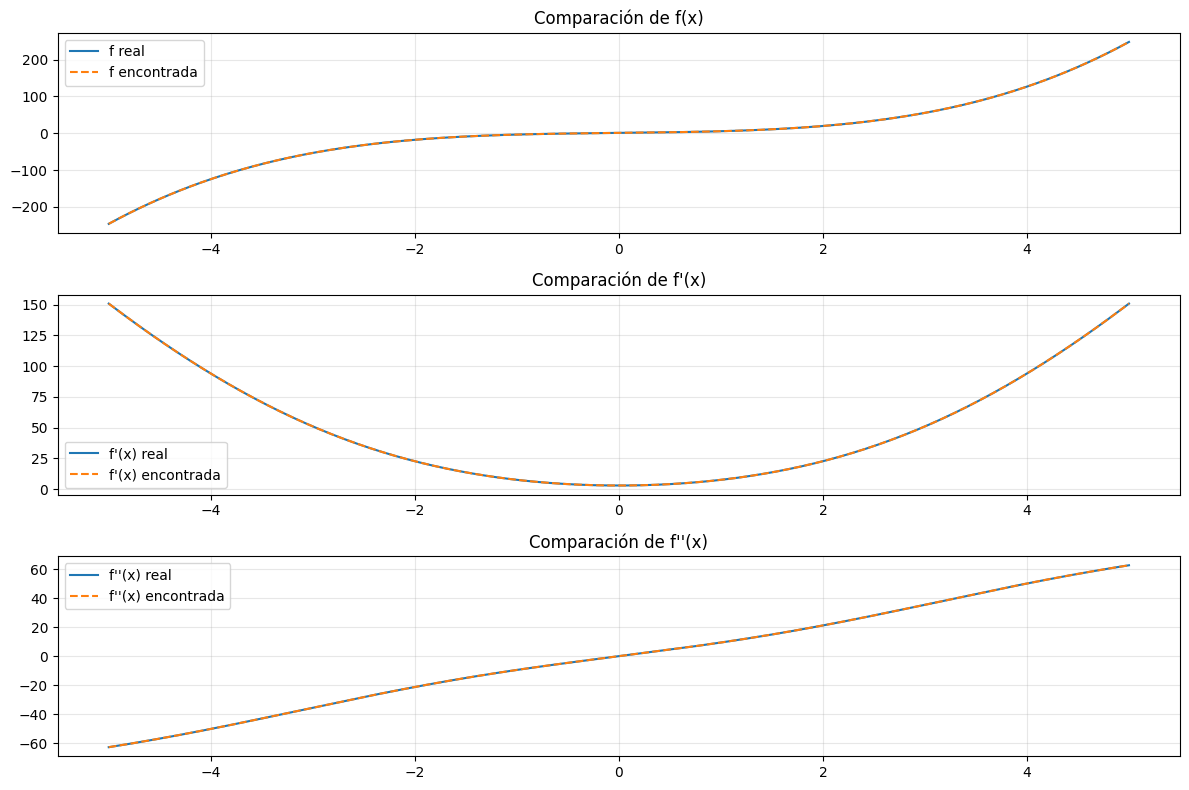

In [7]:
f1_sym = symreg.safe_derivative(f_sym, x, 1)
f2_sym = symreg.safe_derivative(f_sym, x, 2)
f_num = symreg.lambdify_expr(x, f_sym)
f1_num = symreg.lambdify_expr(x, f1_sym)
f2_num = symreg.lambdify_expr(x, f2_sym)

def _a1d(v):
    a = np.asarray(v, dtype=np.float64).reshape(-1)
    return np.full(X.shape, a[0]) if a.size == 1 else a

with np.errstate(all="ignore"):
    Y_pred = _a1d(f_num(X.astype(np.float64)))
    DY_pred = _a1d(f1_num(X.astype(np.float64)))
    DDY_pred = _a1d(f2_num(X.astype(np.float64)))

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(X, 2*X**3 + 3*np.sin(X) + 1, label='f real')
plt.plot(X, Y_pred, '--', label='f encontrada')
plt.title("Comparación de f(x)"); plt.grid(alpha=0.3); plt.legend()
plt.subplot(3, 1, 2)
plt.plot(X, 6*X**2 + 3*np.cos(X), label="f'(x) real")
plt.plot(X, DY_pred, '--', label="f'(x) encontrada")
plt.title("Comparación de f'(x)"); plt.grid(alpha=0.3); plt.legend()
plt.subplot(3, 1, 3)
plt.plot(X, 12*X - 3*np.sin(X), label="f''(x) real")
plt.plot(X, DDY_pred, '--', label="f''(x) encontrada")
plt.title("Comparación de f''(x)"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.savefig("assets/resultado.png", dpi=110, bbox_inches="tight")
plt.show()

## Probabilidades finales del AOS

In [8]:
def show_probs(titulo, scores, tau=0.8):
    names = list(scores.keys())
    if not names:
        print(titulo, "(catálogo vacío)"); return
    v = np.array([scores[n] for n in names], dtype=np.float64)
    p = np.exp((v - v.max())/max(1e-6, tau)); p = p/p.sum()
    print(titulo)
    for i in np.argsort(-p):
        print(f"  {names[i]:>12s}: {p[i]:.3f}")

show_probs("Probabilidades unarias (finales):", aos.un_scores)
show_probs("Probabilidades binarias (finales):", aos.bin_scores)

Probabilidades unarias (finales):
           abs: 0.167
           cos: 0.167
           sin: 0.167
           log: 0.167
           neg: 0.167
          sqrt: 0.167
Probabilidades binarias (finales):
           mul: 0.200
           sub: 0.200
           add: 0.200
           div: 0.200
           pow: 0.200


## Modo EML puro (Fase 4) — se activa con `config.EML_MODE = "pure"`
`eml(x,y) = exp(x) - ln(y)` (Odrzywolek, arXiv:2603.21852): multi-starts en
paralelo por lotes con init desde una evolución eml-only.

In [9]:
if config.EML_MODE == "pure":
    t3 = time.time()
    best_eml, mse_eml = symreg.eml_pure_fit(X, Y, verbose=True)
    print("EML puro:", best_eml.to_text()[:200])
    print(f"MSE={mse_eml:.6g}  t={time.time()-t3:.1f}s")
    config.EML_SYMPY_EXPAND = False
    display(sp.Eq(sp.Symbol('f_eml'), symreg.to_sympy(best_eml)[0]))
    config.EML_SYMPY_EXPAND = True
    display(sp.Eq(sp.Symbol('f_eml_exp'), symreg.to_sympy(best_eml)[0]))
else:
    print("EML_MODE =", config.EML_MODE, "(usa config.EML_MODE='pure' u 'operator' para activar eml)")

EML_MODE = off (usa config.EML_MODE='pure' u 'operator' para activar eml)
